# Dataset Analysis — CNC Turning Roughness & Tool Wear (adorigueto)

**Machine:** ROMI E280 | **Material:** AISI H13 steel | **Data type:** Tabular (aggregated)

**Dataset URL:** https://www.kaggle.com/datasets/adorigueto/cnc-turning-roughness-forces-and-tool-wear
**GitHub:** https://github.com/adorigueto/Prediction-with-ANN

This notebook provides a thorough analysis of the ITA Brazil turning dataset:
- Exp1 (new tool) and Exp2 (3 wear levels) inspection
- Cutting parameter effects on Ra and VBB
- Force distribution by wear level
- Correlation and ANOVA-style analysis
- ML models: predict Ra and VBB
- Feature importance and SHAP-style analysis

## 0. Setup & Configuration

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

# ── CONFIGURATION ────────────────────────────────────────────
EXP1_PATH = '../dataset_2/Exp1.csv'
EXP2_PATH = '../dataset_2/Exp2.csv'
PREP_PATH = '../dataset_2/Prep.csv'

WEAR_LABELS = {0: 'New (0mm)', 1: 'Mid-life (0.1mm)', 2: 'End-of-life (0.3mm)'}
WEAR_COLORS = {0: '#2E7D32', 1: '#E65100', 2: '#B71C1C'}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('✅ Configuration loaded')

✅ Configuration loaded


## 1. Data Loading & Inspection

In [12]:
exp1 = pd.read_csv(EXP1_PATH)
exp2 = pd.read_csv(EXP2_PATH)

# Auto-detect column roles
all_cols = list(exp2.columns)
param_cols  = [c for c in all_cols if any(k in c.lower() for k in ['vc','feed','ap','depth','speed','f_','avance'])]
force_cols  = [c for c in all_cols if any(k in c.lower() for k in ['fx','fy','fz','force'])]
ra_col      = next((c for c in all_cols if 'ra' == c.lower() or c.lower().startswith('ra')), None)
vbb_col     = next((c for c in all_cols if 'vbb' in c.lower() or 'wear' in c.lower() or 'vb' == c.lower()), None)
tool_col    = next((c for c in all_cols if 'tcond' in c.lower() or 'cond' in c.lower()), None)

print('Column detection:')
print(f'  Cutting params : {param_cols}')
print(f'  Force cols     : {force_cols}')
print(f'  Ra column      : {ra_col}')
print(f'  VBB column     : {vbb_col}')
print(f'  Tool cond col  : {tool_col}')
print()

print('=== EXP1 — New Tool Condition ===')
print(f'{exp1.shape[0]} samples × {exp1.shape[1]} columns')
display(exp1.describe().round(3))

print('\n=== EXP2 — Variable Wear ===')
print(f'{exp2.shape[0]} samples × {exp2.shape[1]} columns')
if tool_col:
    print(f'Wear levels: {sorted(exp2[tool_col].unique())}')
display(exp2.describe().round(3))

Column detection:
  Cutting params : ['ap', 'vc']
  Force cols     : ['Fx', 'Fy', 'Fz']
  Ra column      : Ra
  VBB column     : None
  Tool cond col  : Condition

=== EXP1 — New Tool Condition ===
324 samples × 27 columns


,Experiment,Replica,Tool_ID,Group,Subgroup,Condition,TCond,Machined_length,Init_diameter,Final_diameter,...,Ra,Rz,Rsk,Rku,RSm,Rt,Fx,Fy,Fz,F
count,324.0,324.000,324.000,324.000,324.000,324.000,324.0,324.0,324.000,324.000,...,324.000,324.000,324.000,324.000,324.000,324.000,324.000,324.000,324.000,324.000
mean,1.0,1.500,46.000,2.000,5.000,14.000,0.0,12.0,91.783,90.750,...,0.716,3.040,0.387,2.190,98.796,3.222,145.106,66.939,92.396,187.948
std,0.0,0.501,17.105,0.818,2.586,7.801,0.0,0.0,1.673,1.887,...,0.330,1.257,0.335,0.384,24.878,1.269,72.080,16.412,72.711,97.453
min,1.0,1.000,21.000,1.000,1.000,1.000,0.0,12.0,89.400,87.800,...,0.211,1.073,-0.483,1.494,47.500,1.214,49.230,41.600,18.870,69.338
25%,1.0,1.000,31.000,1.000,3.000,7.000,0.0,12.0,90.400,89.400,...,0.452,1.991,0.138,1.900,71.200,2.234,80.140,56.550,25.760,103.298
50%,1.0,1.500,46.000,2.000,5.000,14.000,0.0,12.0,91.700,90.650,...,0.643,2.703,0.418,2.127,100.600,2.899,142.700,61.730,68.600,173.206
75%,1.0,2.000,61.000,3.000,7.000,21.000,0.0,12.0,93.500,92.500,...,0.929,3.987,0.637,2.390,128.800,4.208,177.500,78.350,125.200,221.922
max,1.0,2.000,71.000,3.000,9.000,27.000,0.0,12.0,94.000,93.500,...,1.812,6.548,1.095,3.403,138.100,6.699,289.600,100.700,227.500,377.573



=== EXP2 — Variable Wear ===
288 samples × 27 columns
Wear levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


,Experiment,Replica,Tool_ID,Group,Condition,TCond,Machined_length,Init_diameter,Final_diameter,R_measurement,...,Ra,Rz,Rsk,Rku,RSm,Rt,Fx,Fy,Fz,F
count,288.0,288.000,288.000,288.000,288.000,288.000,288.0,288.000,288.000,288.000,...,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000
mean,2.0,1.500,41.000,3.500,12.500,0.133,12.0,84.767,84.017,3.500,...,0.646,2.906,0.515,2.390,90.554,3.173,127.558,122.586,83.591,199.448
std,0.0,0.501,22.099,1.711,6.934,0.125,0.0,2.490,2.585,1.711,...,0.269,1.079,0.335,0.574,27.982,1.162,47.136,64.079,51.496,86.491
min,2.0,1.000,13.000,1.000,1.000,0.000,12.0,76.600,75.600,1.000,...,0.142,0.706,-0.285,1.443,31.400,0.840,51.500,44.640,24.170,73.725
25%,2.0,1.000,23.000,2.000,6.750,0.000,12.0,84.100,83.600,2.000,...,0.464,2.167,0.270,1.967,69.775,2.380,91.965,71.072,45.552,130.878
50%,2.0,1.500,38.000,3.500,12.500,0.100,12.0,85.350,84.600,3.500,...,0.613,2.762,0.512,2.316,89.900,3.021,117.700,102.850,75.875,184.038
75%,2.0,2.000,53.000,5.000,18.250,0.300,12.0,86.600,85.600,5.000,...,0.798,3.649,0.774,2.650,110.825,3.862,163.650,188.150,90.518,238.618
max,2.0,2.000,81.000,6.000,24.000,0.300,12.0,87.100,86.600,6.000,...,1.675,6.855,1.301,4.212,134.400,8.003,230.000,243.700,206.600,384.260


## 2. Distribution Analysis

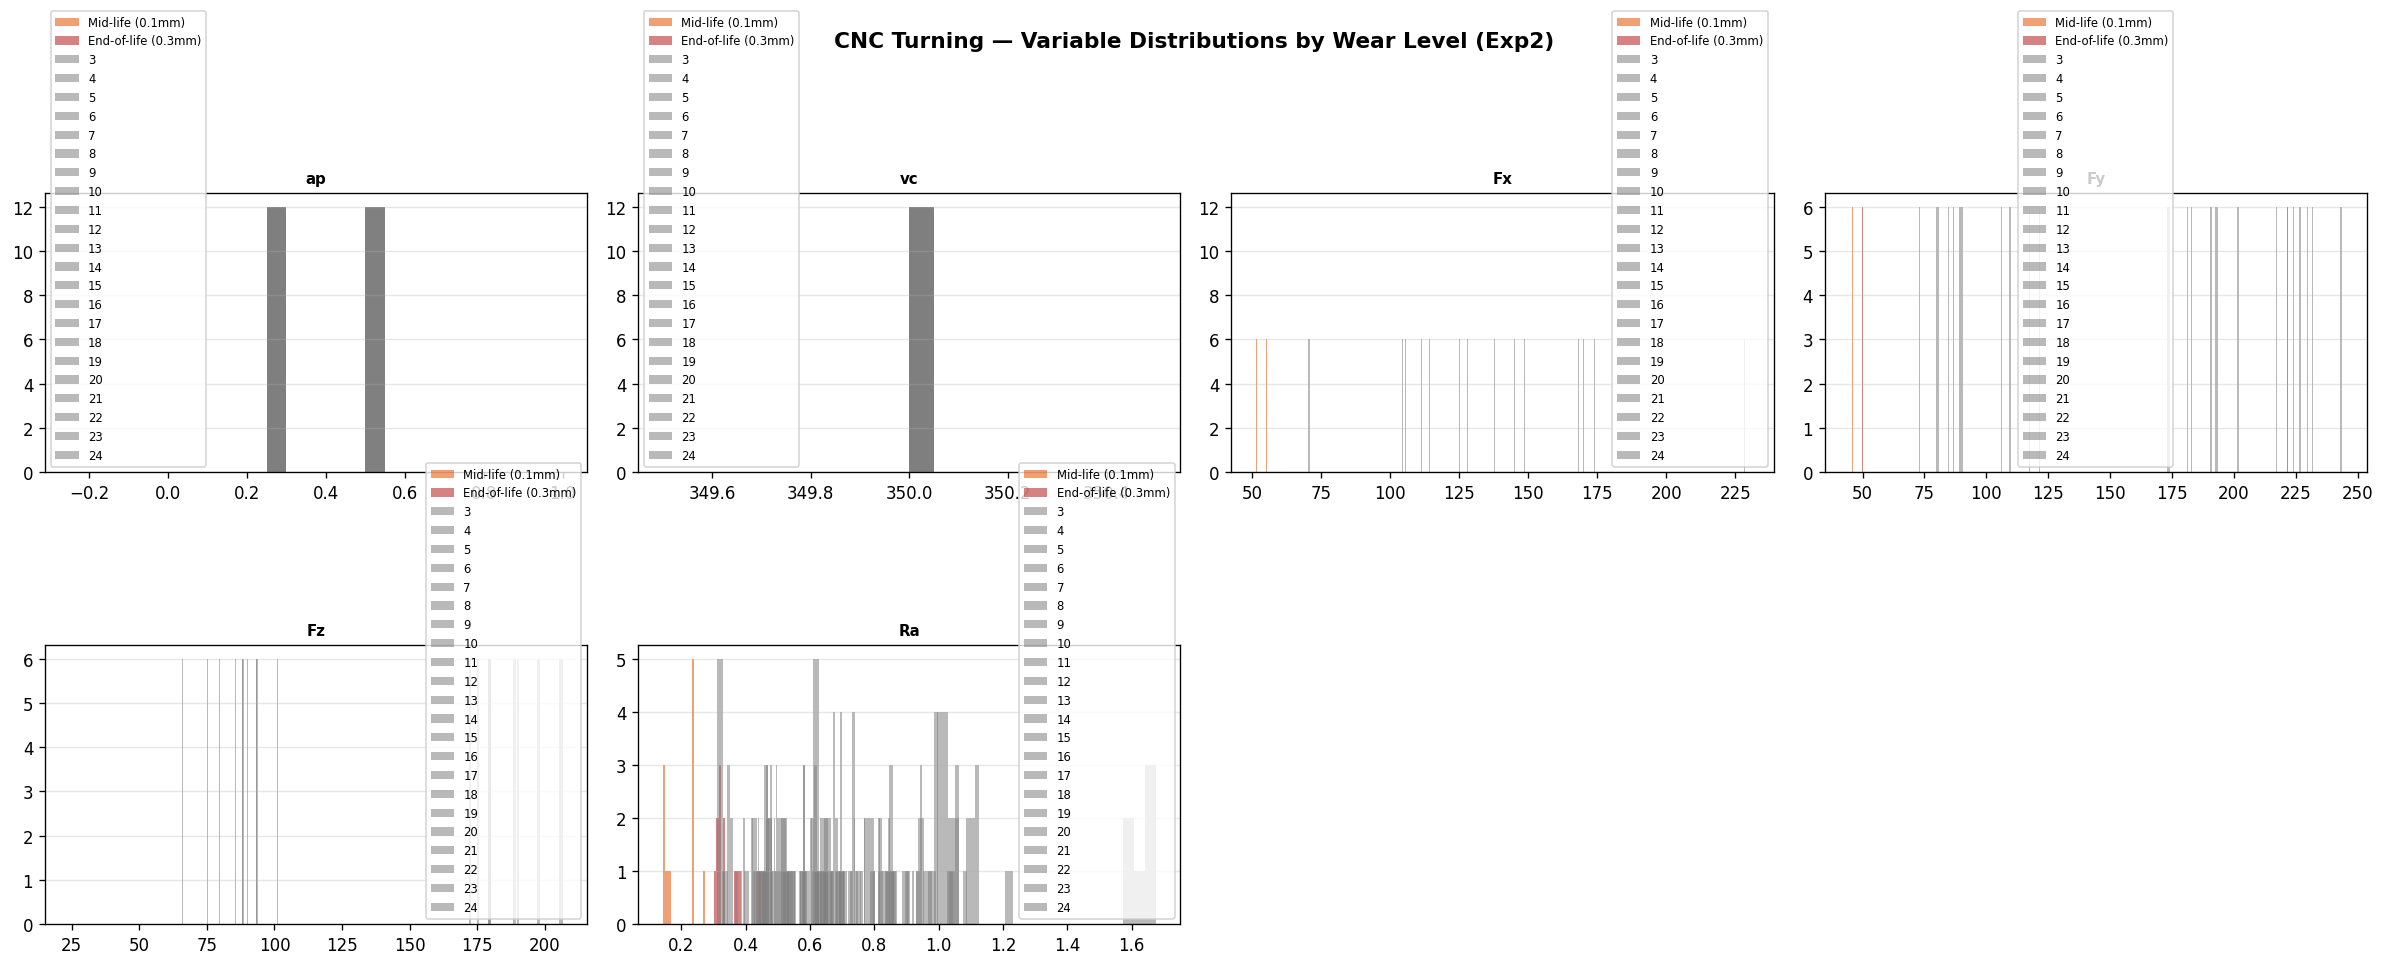

In [13]:
targets_available = [c for c in [ra_col, vbb_col] if c is not None]
numerical_cols = param_cols + force_cols + targets_available
numerical_cols = [c for c in numerical_cols if c in exp2.columns]

n_cols = len(numerical_cols)
n_per_row = 4
n_rows_plot = (n_cols + n_per_row - 1) // n_per_row

fig, axes = plt.subplots(n_rows_plot, n_per_row,
                          figsize=(5 * n_per_row, 4 * n_rows_plot))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, col in enumerate(numerical_cols):
    ax = axes_flat[i]
    if tool_col and tool_col in exp2.columns:
        for lvl in sorted(exp2[tool_col].unique()):
            subset = exp2[exp2[tool_col] == lvl][col].dropna()
            ax.hist(subset, bins=20, alpha=0.55,
                     label=WEAR_LABELS.get(lvl, str(lvl)),
                     color=WEAR_COLORS.get(lvl, 'gray'))
        ax.legend(fontsize=7)
    else:
        ax.hist(exp2[col].dropna(), bins=25, color='steelblue', alpha=0.7)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

for j in range(i + 1, len(axes_flat)): axes_flat[j].set_visible(False)
plt.suptitle('CNC Turning — Variable Distributions by Wear Level (Exp2)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Effect of Wear on Forces and Roughness

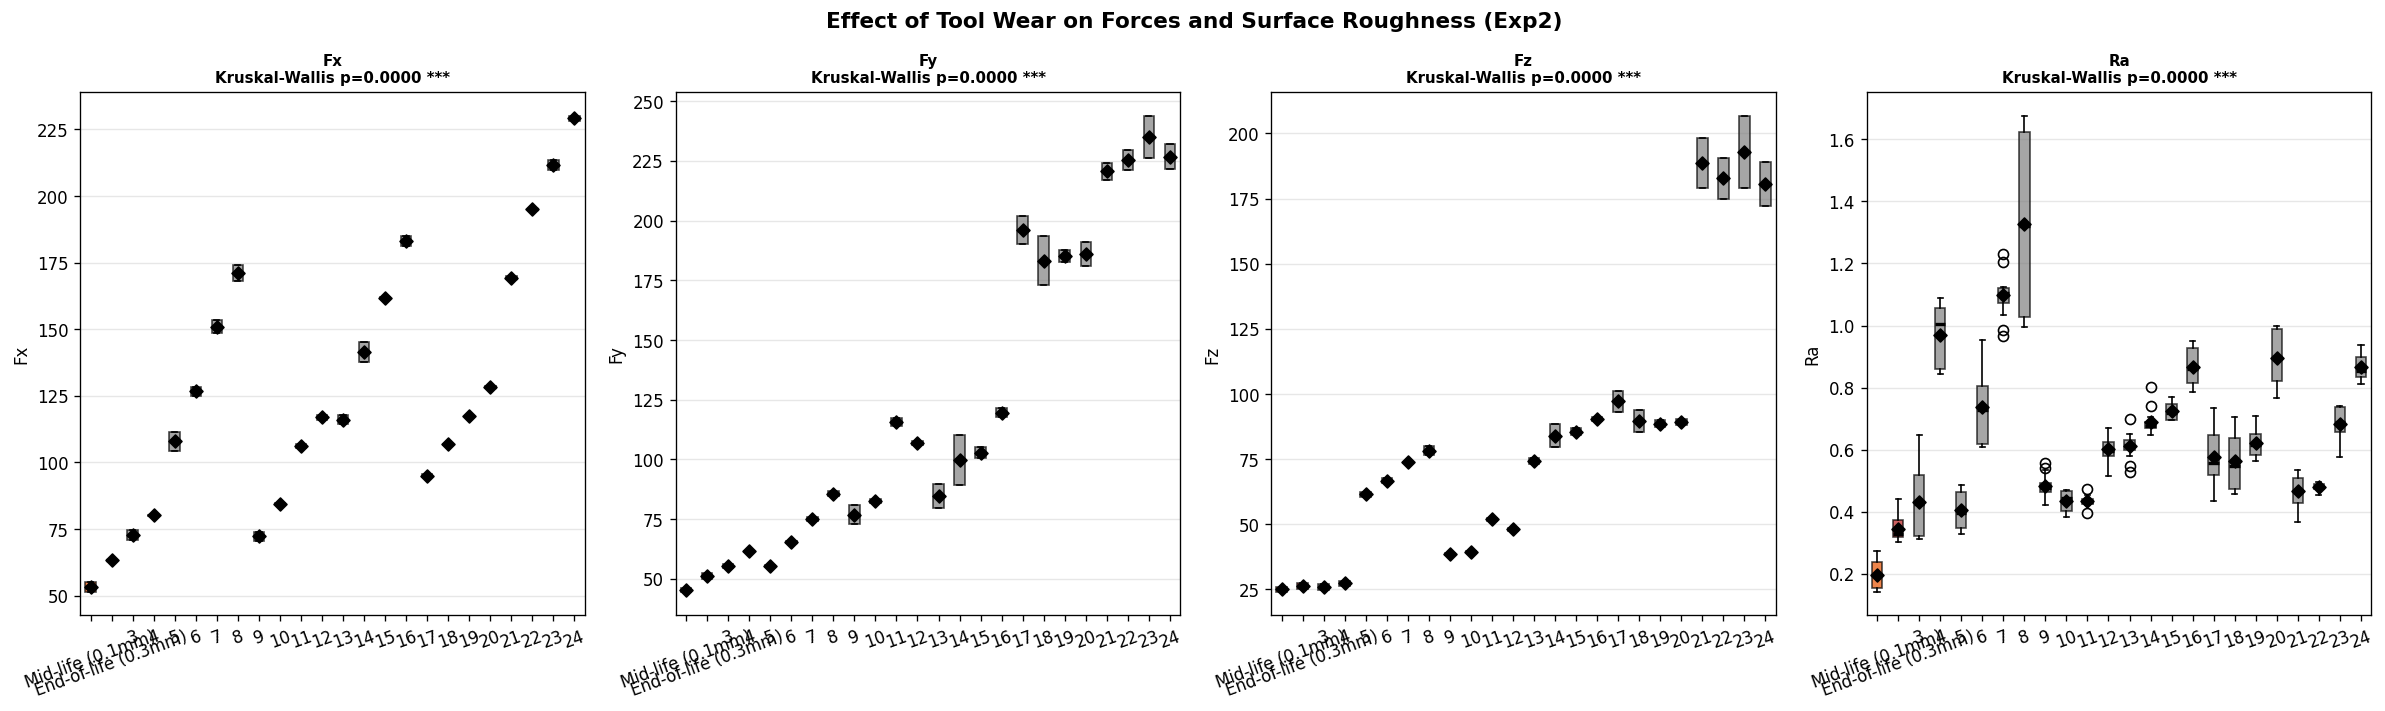

In [14]:
if tool_col:
    cols_to_box = force_cols + ([ra_col] if ra_col else [])
    n_box = len(cols_to_box)
    fig, axes = plt.subplots(1, n_box, figsize=(5 * n_box, 6))
    if n_box == 1: axes = [axes]

    levels = sorted(exp2[tool_col].unique())
    box_colors = [WEAR_COLORS.get(l, 'gray') for l in levels]

    for ax, col in zip(axes, cols_to_box):
        data   = [exp2[exp2[tool_col] == lvl][col].dropna() for lvl in levels]
        labels = [WEAR_LABELS.get(l, str(l)) for l in levels]
        bp     = ax.boxplot(data, labels=labels, patch_artist=True,
                              medianprops={'color':'black','linewidth':2})
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color); patch.set_alpha(0.7)

        # Add mean markers
        for i, d in enumerate(data):
            ax.scatter(i + 1, d.mean(), color='black', s=30, zorder=5, marker='D')

        # Statistical test: Kruskal-Wallis
        h_stat, p_val = stats.kruskal(*data)
        sig_label = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        ax.set_title(f'{col}\nKruskal-Wallis p={p_val:.4f} {sig_label}', fontweight='bold', fontsize=9)
        ax.set_ylabel(col)
        ax.tick_params(axis='x', rotation=20)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Effect of Tool Wear on Forces and Surface Roughness (Exp2)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Cutting Parameter Effects on Ra (Exp1 — New Tool)

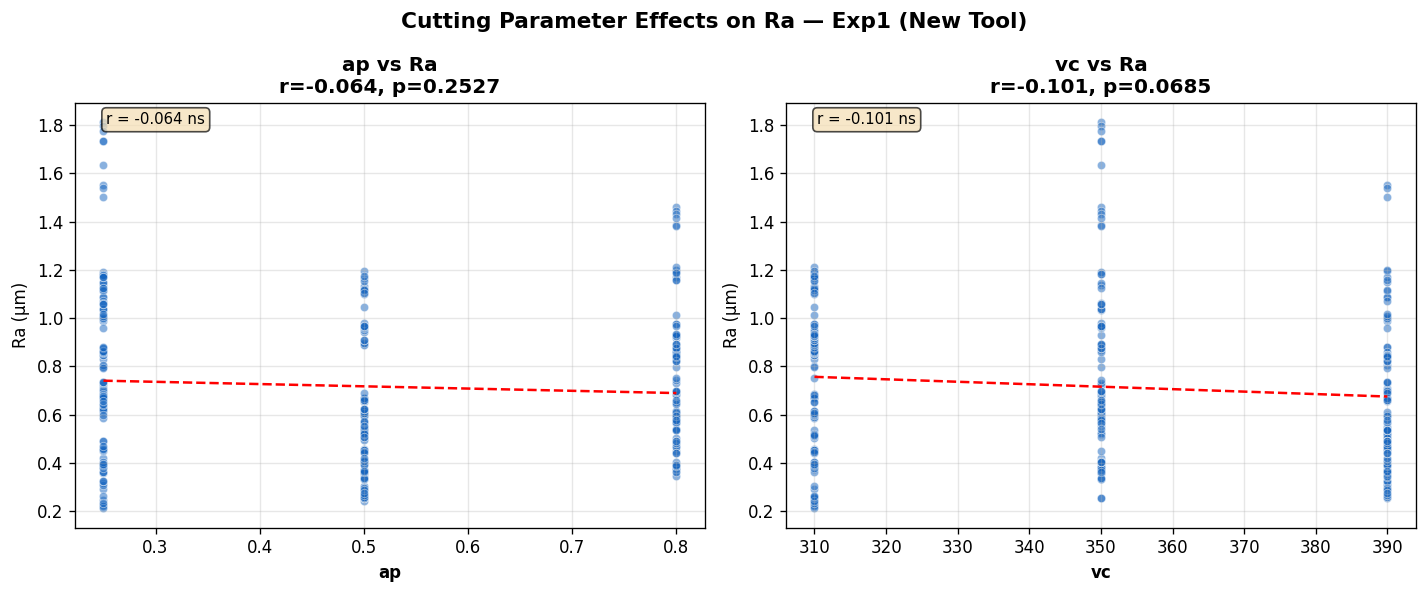

In [15]:
exp1_params = [c for c in param_cols if c in exp1.columns]

if ra_col and ra_col in exp1.columns and exp1_params:
    fig, axes = plt.subplots(1, len(exp1_params), figsize=(6 * len(exp1_params), 5))
    if len(exp1_params) == 1: axes = [axes]

    for ax, col in zip(axes, exp1_params):
        x = exp1[col].dropna()
        y = exp1.loc[x.index, ra_col]
        ax.scatter(x, y, alpha=0.5, s=25, color='#1565C0', edgecolors='white', linewidth=0.5)
        # Regression line
        slope, intercept, r, p, _ = stats.linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 100)
        ax.plot(xfit, slope * xfit + intercept, 'r--', linewidth=1.5)
        ax.set_xlabel(col, fontweight='bold')
        ax.set_ylabel('Ra (µm)' if 'ra' in str(ra_col).lower() else ra_col)
        ax.set_title(f'{col} vs Ra\nr={r:.3f}, p={p:.4f}', fontweight='bold')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.text(0.05, 0.95, f'r = {r:.3f} {sig}', transform=ax.transAxes,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Cutting Parameter Effects on Ra — Exp1 (New Tool)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Full Correlation Matrix (Exp2)

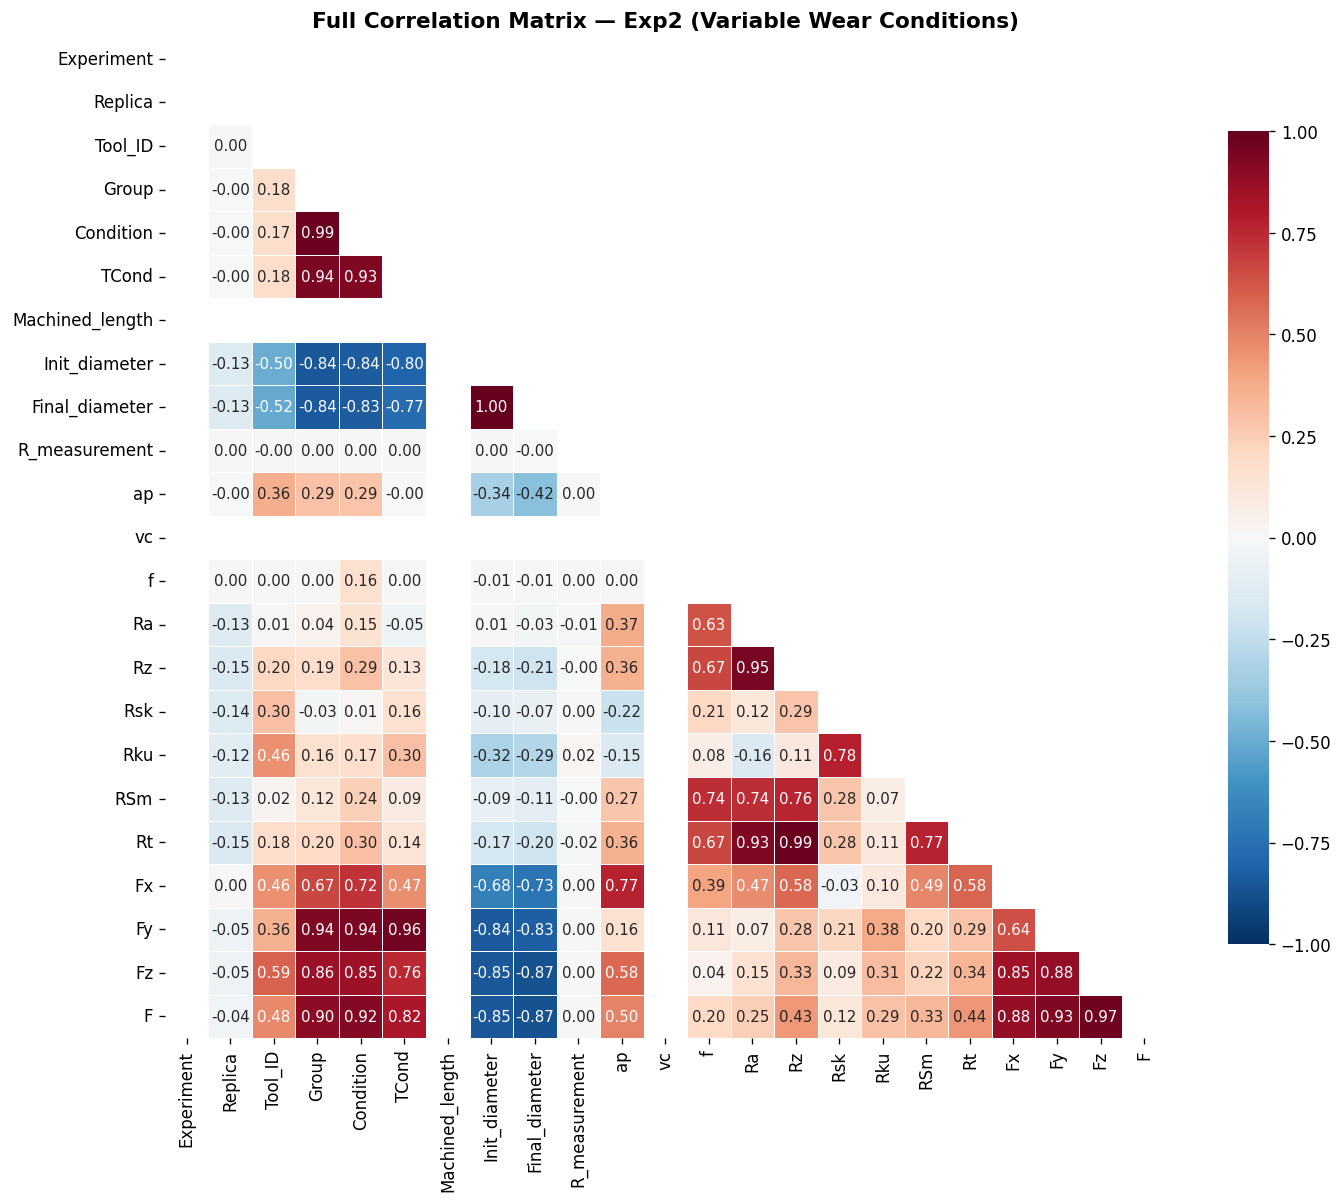

Top correlations with Ra:
Rz     0.9484
Rt     0.9339
RSm    0.7369
f      0.6328
Fx     0.4707
ap     0.3741
F      0.2498
Rku   -0.1553
Name: Ra, dtype: float64


In [16]:
num_cols2 = exp2.select_dtypes(include=[np.number]).columns.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr2 = exp2[num_cols2].corr()
mask  = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
             center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5,
             cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
ax.set_title('Full Correlation Matrix — Exp2 (Variable Wear Conditions)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if ra_col in num_cols2:
    corr_ra = corr2[ra_col].drop(ra_col).sort_values(key=abs, ascending=False)
    print(f'Top correlations with {ra_col}:')
    print(corr_ra.head(8).round(4))

## 6. ML Models — Predict Ra and VBB

In [17]:
import math

input_cols = param_cols + force_cols
input_cols = [c for c in input_cols if c in exp2.columns]
targets    = {}
if ra_col  and ra_col  in exp2.columns: targets['Ra']  = ra_col
if vbb_col and vbb_col in exp2.columns: targets['VBB'] = vbb_col

kf = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
}

results_all = []
if input_cols and targets:
    X = exp2[input_cols].dropna()
    for tgt_name, tgt_col in targets.items():
        y = exp2.loc[X.index, tgt_col]
        mask_valid = y.notna()
        X_t, y_t = X[mask_valid], y[mask_valid]

        print(f'\n--- Target: {tgt_name} ({tgt_col}) ---')
        for mname, model in models.items():
            cv_res = cross_validate(model, X_t, y_t, cv=kf,
                                     scoring=['neg_mean_absolute_error',
                                               'neg_root_mean_squared_error', 'r2'])
            mae  = -cv_res['test_neg_mean_absolute_error'].mean()
            rmse = -cv_res['test_neg_root_mean_squared_error'].mean()
            r2   = cv_res['test_r2'].mean()
            results_all.append({'Target': tgt_name, 'Model': mname,
                                 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
                                 'R²': round(r2, 3)})
            print(f'  {mname:22s}: MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.3f}')

    df_ml_results = pd.DataFrame(results_all)
    display(df_ml_results)


--- Target: Ra (Ra) ---
  Random Forest         : MAE=0.0282 | RMSE=0.0407 | R²=0.972
  Gradient Boosting     : MAE=0.0315 | RMSE=0.0425 | R²=0.970
  Linear Regression     : MAE=0.1475 | RMSE=0.1951 | R²=0.444


,Target,Model,MAE,RMSE,R²
0,Ra,Random Forest,0.0282,0.0407,0.972
1,Ra,Gradient Boosting,0.0315,0.0425,0.970
2,Ra,Linear Regression,0.1475,0.1951,0.444


## 7. Predicted vs Actual + Feature Importance (Best Model)

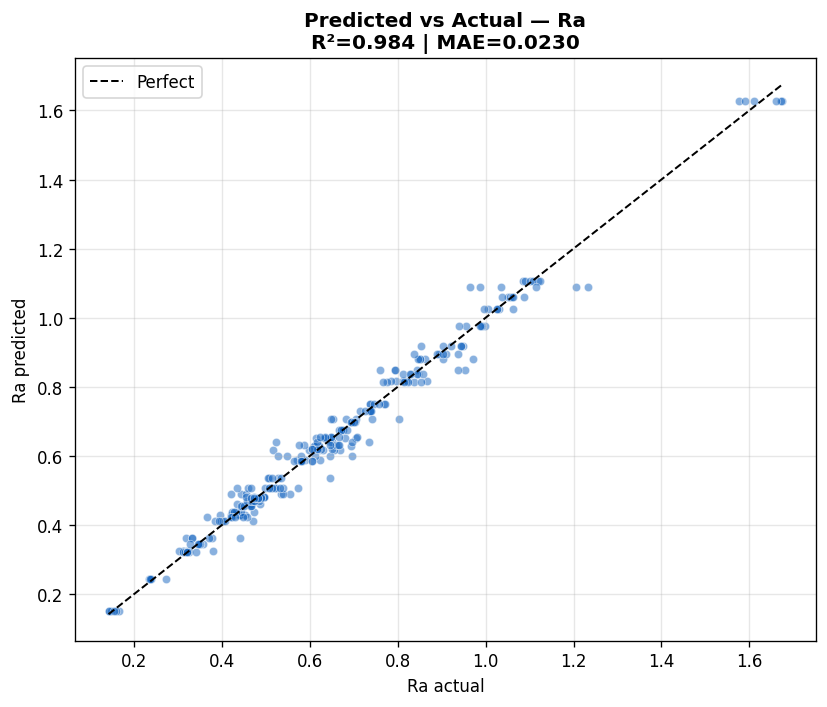

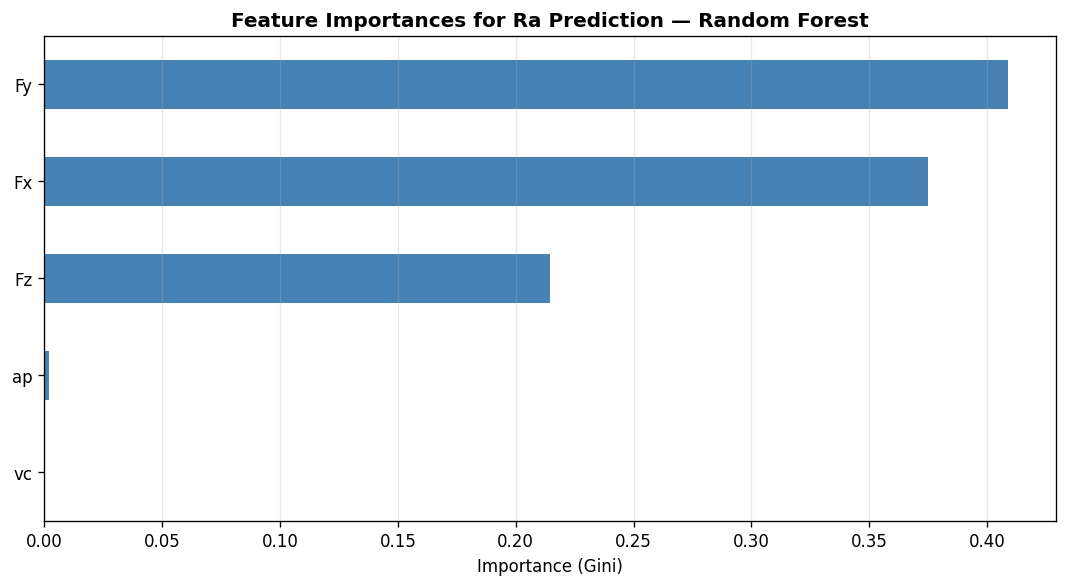

In [18]:
if input_cols and targets:
    fig, axes = plt.subplots(1, len(targets), figsize=(7 * len(targets), 6))
    if len(targets) == 1: axes = [axes]

    for ax, (tgt_name, tgt_col) in zip(axes, targets.items()):
        X_t = exp2[input_cols].dropna()
        y_t = exp2.loc[X_t.index, tgt_col].dropna()
        X_t = X_t.loc[y_t.index]

        rf = RandomForestRegressor(n_estimators=200, random_state=42)
        rf.fit(X_t, y_t)
        y_pred = rf.predict(X_t)

        ax.scatter(y_t, y_pred, alpha=0.5, s=25, color='#1565C0',
                    edgecolors='white', linewidth=0.5)
        lim = [min(y_t.min(), y_pred.min()), max(y_t.max(), y_pred.max())]
        ax.plot(lim, lim, 'k--', linewidth=1.2, label='Perfect')
        ax.set_xlabel(f'{tgt_name} actual'); ax.set_ylabel(f'{tgt_name} predicted')
        r2 = r2_score(y_t, y_pred)
        mae = mean_absolute_error(y_t, y_pred)
        ax.set_title(f'Predicted vs Actual — {tgt_name}\nR²={r2:.3f} | MAE={mae:.4f}',
                      fontweight='bold')
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Feature importance for Ra
    if ra_col and ra_col in exp2.columns:
        y_ra = exp2.loc[X_t.index, ra_col].dropna()
        X_ra = X_t.loc[y_ra.index]
        rf_ra = RandomForestRegressor(n_estimators=200, random_state=42)
        rf_ra.fit(X_ra, y_ra)
        imp = pd.Series(rf_ra.feature_importances_, index=input_cols)

        fig, ax = plt.subplots(figsize=(9, 5))
        imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title('Feature Importances for Ra Prediction — Random Forest',
                      fontweight='bold')
        ax.set_xlabel('Importance (Gini)')
        ax.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

## 8. Model Comparison Visualization

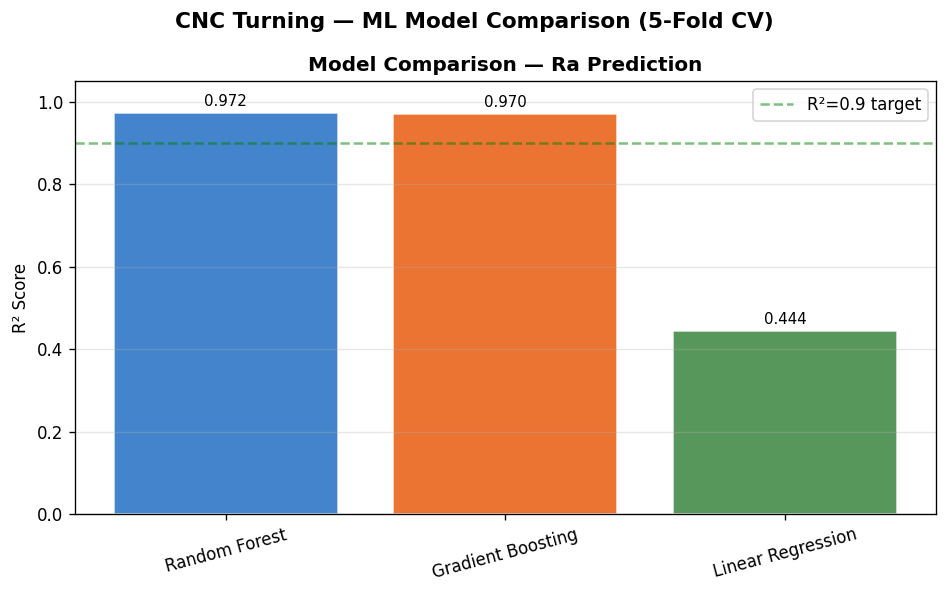

In [19]:
if 'df_ml_results' in dir() and not df_ml_results.empty:
    fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5))
    if len(targets) == 1: axes = [axes]

    metric_colors = {'Random Forest': '#1565C0',
                      'Gradient Boosting': '#E65100',
                      'Linear Regression': '#2E7D32'}

    for ax, tgt_name in zip(axes, targets.keys()):
        sub = df_ml_results[df_ml_results['Target'] == tgt_name]
        x   = np.arange(len(sub))
        bars = ax.bar(x, sub['R²'], color=[metric_colors[m] for m in sub['Model']],
                       alpha=0.8, edgecolor='white')
        ax.set_xticks(x); ax.set_xticklabels(sub['Model'], rotation=15)
        ax.set_ylabel('R² Score')
        ax.set_title(f'Model Comparison — {tgt_name} Prediction', fontweight='bold')
        ax.set_ylim([0, 1.05])
        ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='R²=0.9 target')
        for bar, (_, row) in zip(bars, sub.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{row["R²"]:.3f}', ha='center', va='bottom', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y'); ax.legend()

    plt.suptitle('CNC Turning — ML Model Comparison (5-Fold CV)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9. Summary

In [20]:
print('=' * 55)
print('CNC TURNING — ANALYSIS SUMMARY')
print('=' * 55)
print(f'Exp1 samples : {len(exp1)} (new tool)')
print(f'Exp2 samples : {len(exp2)} (3 wear levels)')
print(f'Total        : {len(exp1)+len(exp2)}')
print(f'Features used for ML: {input_cols}')
if 'df_ml_results' in dir():
    print('\nBest model results:')
    display(df_ml_results.loc[df_ml_results.groupby('Target')['R²'].idxmax()])

CNC TURNING — ANALYSIS SUMMARY
Exp1 samples : 324 (new tool)
Exp2 samples : 288 (3 wear levels)
Total        : 612
Features used for ML: ['ap', 'vc', 'Fx', 'Fy', 'Fz']

Best model results:


,Target,Model,MAE,RMSE,R²
0,Ra,Random Forest,0.0282,0.0407,0.972
